# SQL 01 — Getting the data out: `SELECT`, `WHERE`, `GROUP BY`

**Time:** about 2.5 hours. Roughly 30 minutes of reading and demonstration; the rest is you
writing SQL with your own hands.

## 📚 Learning objectives

By the end of this notebook you can:

- Read a table's **schema** and say in one sentence what a single row of it means.
- Write `SELECT ... FROM ... WHERE ... ORDER BY ... LIMIT` to answer a question somebody asked.
- Turn 25,000 rows into an answer with `GROUP BY` and `COUNT`, `SUM` and `AVG`.
- Filter *groups* with `HAVING`, and say why `WHERE` cannot do that job.
- Answer the **same question** in pandas and in SQL, and say which tool the situation calls for.
- Recognise a query that runs cleanly, raises nothing, and returns a **wrong number**.

## Why this notebook exists

The 12 official courses of this diploma contain no SQL. This folder exists because of what the
job market asked for. A scan of **322 real job postings** collected for this programme — 183 of
them located in Saudi Arabia, 74 of them junior-plausible — found **SQL named in 63 of the 183
Saudi postings (34%)** and in **21 of the 74 junior ones (28%)**. That is roughly **four times**
more often than "deep learning" or "neural network" (15 of 183, 8%) and **five times** more often
than scikit-learn (13 of 183, 7%).

A Riyadh fintech posting for a Data Analyst, recorded in that same scan, does not ask for "SQL"
in the abstract:

> "Strong SQL. You can write and debug complex joins, window functions, and CTEs against a large
> transactional schema without hand-holding." … "Ability to scope a vague business question into
> something answerable, and to say clearly when the data can't answer it."

You cannot debug a join before you can write a `WHERE`. **This notebook is the floor that
sentence stands on**, and the sample database below is the one lessons 02 and 03 keep using.

## 🔗 Where this fits

**Builds on:** the pandas work in Course 05 — `df[df["x"] == v]`, `.groupby()`, `.value_counts()`.
Every idea here has a pandas twin you already know, and Part 4 puts them side by side on purpose.
It also builds on the profiling of this same 911 call log in Course 05 Unit 1, which found that
**3,025 of these 25,000 rows have no ZIP code**.

**Used later in:** lesson **02** of this folder (`JOIN`, CTEs, window functions) runs on this exact
`calls` table, and lesson **03** hands you broken queries over it and asks you to prove the numbers
wrong. Beyond this folder: Course 05 Unit 4, and any project whose data starts in a database rather
than a CSV — which, in a job, is most of them.

**Not part of the 12 official courses.** See `SQL/README.md` for the honest reason this folder
exists at all.

---

## Part 0 — Set up

Two cells. The first finds the repository and imports the shared data loader; the second builds
the database.

Everything here runs on Python's built-in **`sqlite3`** module. There is nothing to install, no
server to start, no password, and no network needed after the data file is on your disk. It works
identically on Windows, macOS and Google Colab. That is the whole reason this strand uses SQLite:
the SQL you are about to write is the same SQL you will write against a company's warehouse.

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHY not a relative path: '../../Course 04/datasets/...' only resolves when the kernel's
# working directory happens to be this notebook's folder. This walks up to find the repo.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

import hashlib
import sqlite3

import pandas as pd

from tools.data import load

print("SQLite engine version :", sqlite3.sqlite_version)
print("pandas version        :", pd.__version__)

SQLite engine version : 3.52.0
pandas version        : 2.3.3


## The table somebody else designed

The source is the **Montgomery County, Pennsylvania 911 emergency call log** — a real dispatch
record, not a teaching toy. This notebook reads the **25,000-row sample that ships with the
repository** (`prefer="sample"`), which is 1 call in every 27 of the real 663,522-call log, so
**every number below is the same on your machine as on mine** and every total is a *sample*
total, not a county total. Shares and rankings survive that thinning; absolute counts do not.

The next cell does three things: reads the CSV, reshapes it into the columns a dispatch table
would actually have, and loads it into a SQLite table called `calls`. One row is **one emergency
call**.

Two things in it are worth your attention, because both are decisions somebody made *before*
you arrived, and you will live with them:

- The raw file packs the call description into a single `title` column — `EMS: HEAD INJURY`. We
  split it at the colon into `category` (`EMS`, `Fire`, `Traffic`) and `call_type` (`HEAD INJURY`).
  Whoever designs the table decides what is one column and what is two, and everybody who queries
  it afterwards has to live with that choice.
- `twp` (township) and `zip` are allowed to be `NULL`; `ts`, `category` and `call_type` are not.
  `NULL` means *nobody recorded this*, and it will change your answers in Part 3.

In [2]:
raw = load("montgomery_911_calls", prefer="sample")   # prefer="sample": same numbers for everyone

df = pd.DataFrame({
    "ts":        raw["timeStamp"],
    "category":  raw["title"].str.split(":").str[0].str.strip(),
    "call_type": raw["title"].str.split(":").str[1].str.strip().str.rstrip("-").str.strip(),
    "twp":       raw["twp"],
    "zip":       raw["zip"],
    "addr":      raw["addr"],
})
df["call_date"] = df["ts"].str.slice(0, 10)
df["month"]     = df["ts"].str.slice(0, 7)
df["hour"]      = df["ts"].str.slice(11, 13).astype(int)
# Int64 (capital I) is pandas' integer type that allows NULL. Plain int cannot hold the 3,025
# missing ZIPs, and float would store 19422.0 in the database instead of 19422.
df["zip"] = df["zip"].astype("Int64")

# ":memory:" keeps the whole database in RAM: nothing is written to your disk, and re-running
# this cell after a bad experiment gives you a clean database again.
con = sqlite3.connect(":memory:")
con.execute("""
CREATE TABLE calls (
    call_id   INTEGER PRIMARY KEY,
    ts        TEXT    NOT NULL,
    call_date TEXT    NOT NULL,
    month     TEXT    NOT NULL,
    hour      INTEGER NOT NULL,
    category  TEXT    NOT NULL,
    call_type TEXT    NOT NULL,
    twp       TEXT,
    zip       INTEGER,
    addr      TEXT
)""")

cols = ["ts", "call_date", "month", "hour", "category", "call_type", "twp", "zip", "addr"]
rows = [tuple(None if pd.isna(v) else (int(v) if c == "zip" else v)
              for c, v in zip(cols, r))
        for r in df[cols].itertuples(index=False, name=None)]
con.executemany(f"INSERT INTO calls ({','.join(cols)}) VALUES ({','.join('?' * len(cols))})", rows)
con.commit()


def q(sql):
    """Run SQL against the calls database and hand the result back as a DataFrame."""
    return pd.read_sql_query(sql, con)


print("calls table:", q("SELECT COUNT(*) AS n FROM calls").iloc[0, 0], "rows")

montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
calls table: 25000 rows


`q()` is three words of Python wrapped around one pandas function: `pd.read_sql_query(sql, con)`.
That function is the whole bridge between the two halves of your job — **SQL runs the query where
the data lives, pandas receives the answer**. Part 4 comes back to it.

Before you query a table you have never seen, ask it to describe itself. Every database has a way;
in SQLite it is `PRAGMA table_info`.

In [3]:
display(q("PRAGMA table_info(calls)"))
display(q("SELECT * FROM calls LIMIT 5"))

,cid,name,type,notnull,dflt_value,pk
0,0,call_id,INTEGER,0,None,1
1,1,ts,TEXT,1,None,0
2,2,call_date,TEXT,1,None,0
3,3,month,TEXT,1,None,0
4,4,hour,INTEGER,1,None,0
5,5,category,TEXT,1,None,0
6,6,call_type,TEXT,1,None,0
7,7,twp,TEXT,0,None,0
8,8,zip,INTEGER,0,None,0
9,9,addr,TEXT,0,None,0


,call_id,ts,call_date,month,hour,category,call_type,twp,zip,addr
0,1,2015-12-10 18:02:38,2015-12-10,2015-12,18,EMS,HEAD INJURY,WHITPAIN,19422,PENLLYN BLUE BELL PIKE & VILLAGE CIR
1,2,2015-12-10 19:08:43,2015-12-10,2015-12,19,Traffic,ROAD OBSTRUCTION,LANSDALE,19446,W MT VERNON ST & S MITCHELL AVE
2,3,2015-12-10 20:36:49,2015-12-10,2015-12,20,Traffic,VEHICLE ACCIDENT,LOWER MERION,19004,BELMONT AVE & E CITY AVE
3,4,2015-12-10 23:01:58,2015-12-10,2015-12,23,Fire,FIRE ALARM,LOWER MERION,19066,HEATH RD & ZOLLINGER WAY
4,5,2015-12-11 03:47:25,2015-12-11,2015-12,3,EMS,LACERATIONS,CONSHOHOCKEN,19428,WOOD ST & W 5TH AVE


### Read the schema before you write anything

`notnull = 1` on `ts`, `call_date`, `month`, `hour`, `category` and `call_type` means the database
itself refuses a row without them. `notnull = 0` on `twp`, `zip` and `addr` means those are
allowed to be empty — and in this table they sometimes are. `pk = 1` marks `call_id` as the
**primary key**: unique, one per call.

That is the difference between a table and a DataFrame in one sentence: **a DataFrame is a value
you built and can see; a table is a contract somebody else wrote, that outlives you and that you
cannot see all of.** `SELECT * FROM calls` would return 25,000 rows. You will never look at a real
table this way — you ask it questions instead. That is the rest of this notebook.

---

### The checker

You are going to write a lot of SQL in this notebook — five short tasks in the middle and seven
exercises at the end. `check("T1", sql)` runs your query, shows the result, and compares a
**fingerprint** of it against the expected one.

It never shows you the answer. It does tell you the shape it expected and how many of your rows
are right, so a near miss is debuggable. Column *names* are ignored; column **order** is not, so
return the columns in the order the task lists them.

Run this cell once.

In [4]:
EXPECTED = {
    "T1": {
        "shape": [
            3,
            4
        ],
        "rows": [
            "32baaf635480",
            "536d6efa81f9",
            "73cc022a93b8"
        ],
        "ordered": "1d25b0e0d1e2"
    },
    "T2": {
        "shape": [
            1,
            1
        ],
        "rows": [
            "7045d16ae7f0"
        ],
        "ordered": "7045d16ae7f0"
    },
    "T3": {
        "shape": [
            5,
            2
        ],
        "rows": [
            "20907c8e19dd",
            "541ddc8e4e46",
            "93ac10fed984",
            "982be465e8c5",
            "c2587f031152"
        ],
        "ordered": "b707c92bc8b8"
    },
    "E1": {
        "shape": [
            5,
            3
        ],
        "rows": [
            "31cb4d57c90d",
            "48dfa764d585",
            "623835f569d7",
            "9b6d15b8066d",
            "efbb62935ac0"
        ],
        "ordered": "c5257f5834c8"
    },
    "E2": {
        "shape": [
            1,
            2
        ],
        "rows": [
            "d0e17842b59d"
        ],
        "ordered": "d0e17842b59d"
    },
    "E3": {
        "shape": [
            5,
            2
        ],
        "rows": [
            "3b7c879bac1b",
            "694f5778d27a",
            "7dd5de987bb5",
            "cce94d25b536",
            "d886851c304d"
        ],
        "ordered": "8c5a01b63290"
    },
    "E4": {
        "shape": [
            12,
            2
        ],
        "rows": [
            "12c54a58368f",
            "2115e91e7dfb",
            "2894b7f03ff5",
            "4b5eafd83f90",
            "6268f8a9b297",
            "7ba9435fbedc",
            "819b4e7c3620",
            "c3903a574776",
            "d5f9748f63ef",
            "d8f04b642723",
            "e7bc7ae5199f",
            "f091ddd35b7d"
        ],
        "ordered": "5516222cb2ac"
    },
    "E5": {
        "shape": [
            6,
            3
        ],
        "rows": [
            "0911a726f877",
            "0d353af342a6",
            "395a2c129ef6",
            "48105096ec09",
            "d1a5a575f556",
            "ee4fe87bcb74"
        ],
        "ordered": "6b16bf3743fa"
    },
    "E6": {
        "shape": [
            1,
            1
        ],
        "rows": [
            "b1556dea32e9"
        ],
        "ordered": "b1556dea32e9"
    }
}

def _canon(result):
    """One string per row, so 17 and 17.0 and ' 17 ' all compare equal."""
    out = []
    for row in result.itertuples(index=False, name=None):
        vals = []
        for v in row:
            if isinstance(v, float):
                v = int(v) if float(v).is_integer() else round(v, 4)
            vals.append("NULL" if v is None or (isinstance(v, float) and pd.isna(v))
                        else str(v).strip())
        out.append("|".join(vals))
    return out


def _h(s):
    return hashlib.sha256(s.encode()).hexdigest()[:12]


def check(name, sql):
    body = "\n".join(l for l in sql.splitlines() if not l.strip().startswith("--")).strip()
    if not body:
        print(f"{name}: nothing to check yet — write your query above and run this cell again.")
        return
    try:
        got = q(sql)
    except Exception as e:
        print(f"{name}: SQLite rejected this query — {type(e).__name__}: {e}")
        return
    display(got)
    exp = EXPECTED[name]
    print(f"{name}: your result is {got.shape[0]} rows x {got.shape[1]} columns; "
          f"expected {exp['shape'][0]} x {exp['shape'][1]}.")
    if got.shape[1] != exp["shape"][1]:
        print("   Wrong number of columns — return exactly the columns the task lists, in order.")
        return
    mine = _canon(got)
    hits = sum(1 for r in mine if _h(r) in exp["rows"])
    if hits == len(exp["rows"]) and got.shape[0] == exp["shape"][0]:
        if _h("~".join(mine)) == exp["ordered"]:
            print("   ✅ correct.")
        else:
            print("   ✅ every row is correct, but they are in a different order — "
                  "check your ORDER BY.")
    else:
        print(f"   ❌ {hits} of your {got.shape[0]} rows match the {len(exp['rows'])} "
              "expected rows.")


print("checker ready —", len(EXPECTED), "tasks")

checker ready — 9 tasks


---

## Part 1 — `SELECT`, `ORDER BY`, `LIMIT`: getting a look

A query is built from clauses, and only the first two are compulsory:

| clause | what it decides |
|---|---|
| `SELECT` | which **columns** come back |
| `FROM` | which **table** they come from |
| `WHERE` | which **rows** are kept |
| `GROUP BY` | how rows are **bucketed** before counting |
| `HAVING` | which **buckets** are kept |
| `ORDER BY` | the **order** of the rows you get |
| `LIMIT` | **stop** after this many rows |

They must be written in that order. Here is a question a real person asks:

> **The fire chief:** "What were the last ten building fires, and where?"

In [5]:
q("""
SELECT ts, twp, addr
FROM calls
WHERE call_type = 'BUILDING FIRE'
ORDER BY ts DESC
LIMIT 10
""")

,ts,twp,addr
0,2020-07-16 19:04:47,NORRISTOWN,PENN ST & CHERRY ST
1,2020-07-10 06:15:14,SPRINGFIELD,ALLISON RD & GARTH RD
2,2020-07-06 16:19:54,ABINGTON,EASTON RD & ROSEMORE AVE
3,2020-07-05 22:58:55,UPPER MERION,VALLEY FORGE CIR & OLD VALLEY FORGE RD
4,2020-06-27 23:08:31,POTTSTOWN,LIBERTY ALY
5,2020-06-12 14:18:46,FRANCONIA,AUBURN CT & DEAD END
6,2020-06-05 19:52:54,UPPER PROVIDENCE,3RD AVE & GAY ST
7,2020-05-28 03:21:38,DELAWARE COUNTY,NO LOCATION - NEIGHBORING COUNTY
8,2020-05-27 15:14:57,JENKINTOWN,SUMMIT AVE & WALNUT ST
9,2020-05-26 06:56:47,HATFIELD TOWNSHIP,PENN ST & UNION ST


Ten rows, newest first, three columns out of ten. Read it as an instruction to the database:
*from `calls`, keep the rows where `call_type` is `BUILDING FIRE`, sort them newest first, hand me
the first ten, and only these three columns.*

Three things to notice, because each is a habit:

- **`ORDER BY ts DESC` is not decoration.** Without `ORDER BY`, a database is allowed to hand you
  rows in any order it likes, and `LIMIT 10` then means "any ten rows", not "the latest ten". A
  `LIMIT` without an `ORDER BY` is almost always a bug.
- **`ts` sorts correctly as text** only because it is written `2020-07-16 19:04:47` — year, month,
  day, biggest unit first. Lesson 03 in this folder shows what happens when a date column is
  stored as `07/16/2020` instead. It is not pretty.
- **Text is compared with single quotes** and it is **case-sensitive** here: `'BUILDING FIRE'`
  matches, `'Building Fire'` does not.

SQL is *written* `SELECT` first, but the database *runs* it in a different order:
`FROM` → `WHERE` → `GROUP BY` → `HAVING` → `SELECT` → `ORDER BY` → `LIMIT`. That is not trivia. It
explains, in Part 3, why you can sort by a name you invented in `SELECT` but cannot filter on it in
`WHERE` — when `WHERE` runs, that name does not exist yet.

### ✍️ Task T1 — you write it

Return the **3 most recent calls in `NORRISTOWN`**, with these four columns in this order:
`ts`, `category`, `call_type`, `addr`. Newest first.

Replace the comment with your query and run the cell.

In [6]:
sql = """
-- your query here
"""
check("T1", sql)

T1: nothing to check yet — write your query above and run this cell again.


---

## Part 2 — `WHERE`: asking for the rows you actually want

Everything you can put in a pandas boolean mask has a `WHERE` spelling:

| you want | pandas | SQL |
|---|---|---|
| equals | `df["twp"] == "NORRISTOWN"` | `twp = 'NORRISTOWN'` |
| not equals | `df["category"] != "EMS"` | `category <> 'EMS'` (or `!=`) |
| one of a list | `df["twp"].isin([...])` | `twp IN ('NORRISTOWN', 'POTTSTOWN')` |
| a range, ends included | `df["hour"].between(0, 5)` | `hour BETWEEN 0 AND 5` |
| contains text | `df["call_type"].str.contains("FIRE")` | `call_type LIKE '%FIRE%'` |
| is missing | `df["zip"].isna()` | `zip IS NULL` |
| both | `&` | `AND` |
| either | `\|` | `OR` |

Two traps in that table, and both cost people real money:

- **`= NULL` never works.** `WHERE zip = NULL` returns nothing at all — not an error, just an
  empty result. `NULL` means *unknown*, and "is this unknown value equal to that unknown value?"
  is itself unknown, never true. Missing values are always tested with `IS NULL` / `IS NOT NULL`.
- **`%` is SQL's wildcard**, not `*`. `LIKE '%FIRE%'` means "FIRE anywhere in the string".

> **The chief again:** "How many fire calls did Norristown log, and what is our commonest kind of
> fire call across the county?"

In [7]:
display(q("""
SELECT COUNT(*) AS fire_calls_in_norristown
FROM calls
WHERE category = 'Fire' AND twp = 'NORRISTOWN'
"""))

display(q("""
SELECT call_type, category, COUNT(*) AS calls
FROM calls
WHERE call_type LIKE '%FIRE%'
GROUP BY call_type, category
ORDER BY calls DESC
"""))

,fire_calls_in_norristown
0,198


,call_type,category,calls
0,FIRE ALARM,Fire,1448
1,FIRE INVESTIGATION,Fire,343
2,ELECTRICAL FIRE OUTSIDE,Fire,191
3,BUILDING FIRE,Fire,186
4,FIRE SPECIAL SERVICE,Fire,150
5,VEHICLE FIRE,Traffic,144
6,VEHICLE FIRE,Fire,117
7,WOODS/FIELD FIRE,Fire,93
8,UNKNOWN TYPE FIRE,Fire,68
9,FIRE POLICE NEEDED,Fire,61


198 fire calls in Norristown. The second result deserves more than a glance, because it says
something the schema does not.

**`FIRE ALARM` appears twice** — 1,448 times with `category = 'Fire'` and **7 times with
`category = 'EMS'`**. `BUILDING FIRE` appears as 186 `Fire` calls and **41 `EMS` calls**.
`VEHICLE FIRE` is spread across all three categories. So **`call_type` does not determine
`category`**: a dispatcher chose both, call by call, and a burning building that went out as a
medical call is a `BUILDING FIRE` in one column and an `EMS` call in the other.

Which means the very first query in this notebook — the fire chief's "last ten building fires",
filtered on `call_type` alone — quietly included calls that somebody categorised as EMS. Scroll
back and look: the eighth row, `2020-05-28 03:21:38` in `DELAWARE COUNTY`, is one of the 41. It
was in the chief's list all along and nothing on screen said so. Is that
wrong? **It depends entirely on what the chief meant, and the database cannot tell you.** You have
to go and ask a person. What you must never do is fail to notice.

One more thing that result shows: `LIKE '%FIRE%'` swept in `ELECTRICAL FIRE OUTSIDE` and
`WOODS/FIELD FIRE`, which you probably wanted, and it would sweep in `FIREWORKS` if such a type
existed, which you probably did not. **A wildcard is a guess about spelling.** Print what it
matched before you trust the total it produced.

Now the missing data, because it decides answers in Part 3:

In [8]:
display(q("""
SELECT COUNT(*)              AS all_rows,
       COUNT(zip)            AS rows_with_zip,
       COUNT(*) - COUNT(zip) AS rows_with_no_zip
FROM calls
"""))

display(q("SELECT COUNT(*) AS this_is_not_how_you_test_for_null FROM calls WHERE zip = NULL"))

,all_rows,rows_with_zip,rows_with_no_zip
0,25000,21975,3025


,this_is_not_how_you_test_for_null
0,0


**3,025 of the 25,000 calls have no ZIP code** — 12.1% of the table. And the second query, the one
that looks reasonable, returns **0**. Not an error. Zero. Every one of those 3,025 rows is
invisible to `zip = NULL`, and would have been invisible to `zip != 19422` as well.

The first query also shows the difference you will use constantly: **`COUNT(*)` counts rows;
`COUNT(column)` counts rows where that column is not `NULL`.** 25,000 against 21,975. Lesson 03
in this folder is largely about numbers that came out wrong because somebody typed the second one
while meaning the first.

### ✍️ Task T2 — you write it

**One row, one column** named `calls`: how many calls came from `LOWER MERION` during the
overnight hours 0 to 5 inclusive? (The `hour` column is already an integer from 0 to 23.)

In [9]:
sql = """
-- your query here
"""
check("T2", sql)

T2: nothing to check yet — write your query above and run this cell again.


---

## Part 3 — `GROUP BY`: turning 25,000 rows into an answer

Nobody wants 25,000 rows. They want *one number per township*. That is the entire idea of
`GROUP BY`: **put the rows in buckets, then compute one value per bucket**.

> **The county director:** "Which townships call us most?"

In [10]:
q("""
SELECT twp, COUNT(*) AS calls
FROM calls
GROUP BY twp
ORDER BY calls DESC
LIMIT 10
""")

,twp,calls
0,LOWER MERION,2102
1,ABINGTON,1520
2,NORRISTOWN,1515
3,UPPER MERION,1405
4,CHELTENHAM,1161
5,POTTSTOWN,1009
6,LOWER PROVIDENCE,875
7,UPPER MORELAND,858
8,PLYMOUTH,745
9,WHITEMARSH,705


`LOWER MERION` at 2,102, `ABINGTON` at 1,520, `NORRISTOWN` at 1,515. Sixty-eight townships went in,
ten rows came out.

The rule that keeps `GROUP BY` straight in your head: **every column in your `SELECT` must either
be in the `GROUP BY`, or be wrapped in an aggregate function.** `twp` is grouped; `COUNT(*)` is
aggregated; `addr` would be neither, and asking for it is asking "which of these 2,102 addresses
did you want?" (SQLite will actually answer that question rather than refuse — it picks a row for
you. Most other databases reject it. Lesson 03 shows what that permissiveness costs.)

The aggregates you will use every day:

| function | what it does | on `NULL` |
|---|---|---|
| `COUNT(*)` | how many rows in the bucket | counts them all |
| `COUNT(col)` | how many rows have a value in `col` | **skips** `NULL` |
| `COUNT(DISTINCT col)` | how many different values | skips `NULL` |
| `SUM(col)` | total | skips `NULL` |
| `AVG(col)` | mean | skips `NULL` — **including in the denominator** |
| `MIN` / `MAX` | smallest, largest | skips `NULL` |

### `SUM` and `AVG` on a question with no number column

This table has no "revenue" or "response time" to add up. Real tables often do not either, and the
technique analysts reach for is the same in every database: **`CASE WHEN` turns a condition into a
1 or a 0**, and then `SUM` counts them while `AVG` gives you the share.

`CASE WHEN <condition> THEN 1 ELSE 0 END` is SQL's `if`. Read the next query as: *for each
township, how many calls, how many of them were traffic, and what share of them were traffic?*

In [11]:
q("""
SELECT twp,
       COUNT(*)                                                        AS calls,
       SUM(CASE WHEN category = 'Traffic' THEN 1 ELSE 0 END)           AS traffic,
       ROUND(100.0 * AVG(CASE WHEN category = 'Traffic' THEN 1 ELSE 0 END), 1) AS pct_traffic
FROM calls
GROUP BY twp
ORDER BY pct_traffic DESC
LIMIT 8
""")

,twp,calls,traffic,pct_traffic
0,PHILA COUNTY,7,6,85.7
1,WEST CONSHOHOCKEN,213,154,72.3
2,UPPER DUBLIN,699,351,50.2
3,PLYMOUTH,745,374,50.2
4,CHESTER COUNTY,265,128,48.3
5,LOWER GWYNEDD,419,197,47.0
6,UPPER MERION,1405,656,46.7
7,BRYN ATHYN,53,24,45.3


And there is the answer you must never send to the director. **`PHILA COUNTY`, 85.7% traffic** — a
number built on **seven calls**. `WEST CONSHOHOCKEN` at 72.3% has 213. Sort a percentage
descending and the top of the list fills up with the smallest groups, every single time, because
that is where randomness has the most room. This is not a SQL bug; it is the oldest reporting
mistake there is.

`100.0 *`, not `100 *`: in SQL, dividing an integer by an integer gives an integer, and
`100 * (6/7)` would be `0`. The `.0` makes it decimal arithmetic. Lesson 03 shows a real report
ruined by exactly that missing dot.

### `HAVING`: filtering the groups

The fix is to drop the tiny townships. Your first instinct is `WHERE COUNT(*) >= 300`. Try it —
the next cell is **supposed to fail**.

In [12]:
q("""
SELECT twp, COUNT(*) AS calls
FROM calls
WHERE COUNT(*) >= 300
GROUP BY twp
""")

DatabaseError: Execution failed on sql '
SELECT twp, COUNT(*) AS calls
FROM calls
WHERE COUNT(*) >= 300
GROUP BY twp
': misuse of aggregate: COUNT()

`misuse of aggregate: COUNT()`. Remember the running order: `WHERE` runs **before** `GROUP BY`, so
when `WHERE` is deciding about a row, no group exists yet and there is nothing to count. `WHERE`
filters **rows**; it can never see a total.

`HAVING` is the same idea one step later — it filters **groups**, after they are formed:

In [13]:
survivors = q("""
SELECT twp,
       COUNT(*)                                                        AS calls,
       SUM(CASE WHEN category = 'Traffic' THEN 1 ELSE 0 END)           AS traffic,
       ROUND(100.0 * AVG(CASE WHEN category = 'Traffic' THEN 1 ELSE 0 END), 1) AS pct_traffic
FROM calls
GROUP BY twp
HAVING COUNT(*) >= 300
ORDER BY pct_traffic DESC
""")

print(f"{len(survivors)} townships survive HAVING COUNT(*) >= 300, "
      f"out of {q('SELECT COUNT(DISTINCT twp) AS n FROM calls').iloc[0, 0]} in the table")
display(survivors.head(8))

28 townships survive HAVING COUNT(*) >= 300, out of 68 in the table


,twp,calls,traffic,pct_traffic
0,UPPER DUBLIN,699,351,50.2
1,PLYMOUTH,745,374,50.2
2,LOWER GWYNEDD,419,197,47.0
3,UPPER MERION,1405,656,46.7
4,MONTGOMERY,645,287,44.5
5,LOWER MERION,2102,928,44.1
6,WHITEMARSH,705,289,41.0
7,HATFIELD TOWNSHIP,426,171,40.1


Twenty-eight of the 68 townships have 300 calls or more, and now the answer is one you can defend:
**`UPPER DUBLIN` and `PLYMOUTH`, both 50.2% traffic**, on 699 and 745 calls. `LOWER MERION` — the
busiest township in the county — is at 44.1% on 2,102 calls.

Notice that `HAVING COUNT(*) >= 300` repeats the aggregate rather than saying `HAVING calls >= 300`.
SQLite accepts the short form; **PostgreSQL does not**. Its manual is explicit: *"An output
column's name can be used to refer to the column's value in `ORDER BY` and `GROUP BY` clauses, but
not in the `WHERE` or `HAVING` clauses; there you must write out the expression instead."* Writing
the aggregate out in full works everywhere, so make it your habit here.

The 300 is a judgement, not a fact. Say it out loud when you publish: *"townships with at least 300
calls in the sample"*. A threshold you do not state is a threshold nobody can check.

### ✍️ Task T3 — you write it

**Two columns, `call_type` and `calls`, five rows:** the five commonest call types in `NORRISTOWN`,
commonest first.

In [14]:
sql = """
-- your query here
"""
check("T3", sql)

T3: nothing to check yet — write your query above and run this cell again.


### One `GROUP BY`, one picture

`GROUP BY hour` answers a question every emergency service asks: **when are we busiest?** SQL does
the counting; matplotlib draws the 24 numbers it hands back. This is the normal division of labour,
and Part 4 is about why.

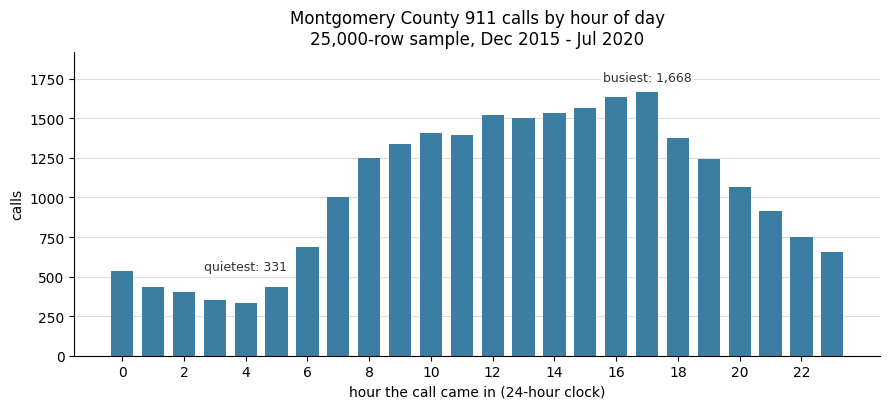

quietest hour: 04:00 -> 331 calls
busiest  hour: 17:00 -> 1,668 calls
the busiest hour is 5.0x the quietest


In [15]:
import matplotlib.pyplot as plt

by_hour = q("""
SELECT hour, COUNT(*) AS calls
FROM calls
GROUP BY hour
ORDER BY hour
""")

peak = by_hour.loc[by_hour["calls"].idxmax()]
trough = by_hour.loc[by_hour["calls"].idxmin()]

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(by_hour["hour"], by_hour["calls"], width=0.72, color="#3B7EA1")
for point, label, lift in ((peak, "busiest", 8), (trough, "quietest", 24)):
    # the quietest bar is surrounded by bars of similar height, so its label is lifted
    # clear of them and given a background of its own
    ax.annotate(f"{label}: {int(point['calls']):,}",
                xy=(point["hour"], point["calls"]), xytext=(0, lift),
                textcoords="offset points", ha="center", fontsize=9, color="#333333",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none",
                          alpha=0.85))
ax.set_ylim(0, by_hour["calls"].max() * 1.15)     # headroom so the peak label is not clipped
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("hour the call came in (24-hour clock)")
ax.set_ylabel("calls")
ax.set_title("Montgomery County 911 calls by hour of day\n25,000-row sample, Dec 2015 - Jul 2020")
ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

print(f"quietest hour: {int(trough['hour']):02d}:00 -> {int(trough['calls']):,} calls")
print(f"busiest  hour: {int(peak['hour']):02d}:00 -> {int(peak['calls']):,} calls")
print(f"the busiest hour is {peak['calls'] / trough['calls']:.1f}x the quietest")

The shape is a working day, not an emergency: a floor at **04:00 (331 calls)**, a climb from
06:00, and a broad afternoon plateau from **12:00 to 17:00** peaking at **17:00 (1,668 calls)**
before it falls away again. Five times as many calls arrive at 17:00 as at 04:00.

Be careful with what that does *not* say. This counts **calls**, not emergencies and not severity;
a rush-hour fender-bender and a cardiac arrest are one row each. The overnight hours are the
quietest and may still be the ones that need the most staff. The chart answers "when does the
phone ring", which is a smaller question than "when do we need people" — and knowing the
difference is most of the job.

---

## Part 4 — The same question in pandas and in SQL

You already know pandas. This part is not here to replace it. It is here so that you can say, in
an interview or in a stand-up, **which of the two you would use and why** — because the honest
answer is not "SQL is faster".

One question, both ways: *the five townships with the most calls.*

In [16]:
import time

SQL = """
SELECT twp, COUNT(*) AS calls
FROM calls
GROUP BY twp
ORDER BY calls DESC
LIMIT 5
"""

t0 = time.perf_counter()
sql_answer = q(SQL)
sql_ms = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
pandas_answer = (df.groupby("twp").size()
                   .sort_values(ascending=False)
                   .head(5)
                   .rename("calls")
                   .reset_index())
pandas_ms = (time.perf_counter() - t0) * 1000

display(sql_answer)
display(pandas_answer)

print(f"same answer             : {sql_answer['calls'].tolist() == pandas_answer['calls'].tolist()}")
print(f"SQL                     : {sql_ms:6.1f} ms")
print(f"pandas                  : {pandas_ms:6.1f} ms")
# deep=True follows each Python string object, so this is the real RAM cost of the DataFrame,
# not just the size of its column pointers.
print(f"RAM held by the DataFrame: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"rows in the answer       : {len(sql_answer)}")

,twp,calls
0,LOWER MERION,2102
1,ABINGTON,1520
2,NORRISTOWN,1515
3,UPPER MERION,1405
4,CHELTENHAM,1161


,twp,calls
0,LOWER MERION,2102
1,ABINGTON,1520
2,NORRISTOWN,1515
3,UPPER MERION,1405
4,CHELTENHAM,1161


same answer             : True
SQL                     :    4.5 ms
pandas                  :    0.8 ms
RAM held by the DataFrame: 11.3 MB
rows in the answer       : 5


Identical answers. And the timings — whichever way round they came out on your machine — are
**both a handful of milliseconds**. Do not learn "SQL is fast" from this; on 25,000 rows already
sitting in your computer's RAM, pandas is frequently the quicker of the two, and the gap is far
too small to be the reason you choose either one.

The number in that output that actually matters is the **RAM held by the DataFrame** — around
11 MB on the machine this notebook was executed on — against **5 rows** of answer. To get those
five rows with pandas, the entire table had to be read off disk and held in memory first. The
SQL version moved five rows.

Now scale that honestly. This sample is 1 call in 27. The real log is **663,522 rows, about
123 MB as a CSV**. A company's transactional table is not 123 MB; the Riyadh posting quoted at the
top says *"a large transactional schema"*, and that usually means tens of gigabytes and a machine
you do not own. **The question is not which is faster. It is where the data lives, and what has to
move.**

| the situation | reach for | why |
|---|---|---|
| The data is in a database and you need a slice of it | **SQL** | the only way in; the server does the work and sends you the answer |
| The table is bigger than your laptop's RAM | **SQL** | pandas must load it all before it can filter; the database does not |
| Filtering, grouping, joining, ranking | **SQL** | this is exactly what the language was built for, and everybody on your team can read it |
| Plotting | **pandas / matplotlib** | SQL cannot draw |
| Reshaping, interpolation, rolling windows, text cleaning | **pandas** | possible in SQL, painful in SQL |
| Training a model, computing features per row | **pandas / scikit-learn** | that is not a set-based question |
| Anything you must repeat every Monday for a year | **SQL** | a query is a text file your colleague can read, review and re-run |

The real workflow is not a choice between them. It is a handover, and the seam is the one function
you have been using since Part 0:

```python
df = pd.read_sql_query("SELECT ... GROUP BY ...", con)   # SQL narrows 50,000,000 rows to 200
df.plot()                                                # pandas does the rest
```

**Cut the data down in SQL, as close to where it lives as possible. Bring back only what you will
actually use.** That single habit is most of what separates an analyst who can work on a real
warehouse from one who cannot.

---

## Part 5 — A query that runs, returns a number, and lies

Everything so far assumed your query says what you meant. Here is the moment SQL stops being a
school exercise.

> **The county director, in an email at 16:50:** "How many EMS or Fire calls came from
> Norristown? I need it for the 17:00 call."

You write the obvious thing. It runs. It returns a number. You send it.

In [17]:
q("""
SELECT COUNT(*) AS calls
FROM calls
WHERE twp = 'NORRISTOWN' AND category = 'EMS' OR category = 'Fire'
""")

,calls
0,4694


**4,694.** No error, no warning, no `NULL`, no empty result. A perfectly formatted, entirely
plausible, completely wrong number — Norristown logged 1,515 calls in total, so a number nearly
three times the size of the whole township has just gone into the director's slide.

Prove it is wrong before theorising about why. The result claims to be about one township, so ask
it which townships it actually contains:

In [18]:
display(q("""
SELECT COUNT(DISTINCT twp) AS townships_in_that_result
FROM calls
WHERE twp = 'NORRISTOWN' AND category = 'EMS' OR category = 'Fire'
"""))

display(q("""
SELECT twp, COUNT(*) AS calls
FROM calls
WHERE twp = 'NORRISTOWN' AND category = 'EMS' OR category = 'Fire'
GROUP BY twp
ORDER BY calls DESC
LIMIT 6
"""))

,townships_in_that_result
0,66


,twp,calls
0,NORRISTOWN,1183
1,LOWER MERION,382
2,ABINGTON,243
3,CHELTENHAM,188
4,UPPER MERION,179
5,POTTSTOWN,156


**66 townships.** `LOWER MERION` contributed 382 calls to a number that was supposed to be about
Norristown, `ABINGTON` another 243.

Now the why. **`AND` binds tighter than `OR`**, exactly as `×` binds tighter than `+` in
arithmetic. SQLite therefore read your `WHERE` as:

```sql
WHERE (twp = 'NORRISTOWN' AND category = 'EMS')   OR   (category = 'Fire')
```

— *Norristown's EMS calls, plus **every Fire call in the county***. And the arithmetic checks out
exactly, which is how you know the diagnosis is right and not just plausible:

In [19]:
display(q("""
SELECT COUNT(*) AS norristown_ems
FROM calls
WHERE twp = 'NORRISTOWN' AND category = 'EMS'
"""))

display(q("""
SELECT COUNT(*) AS every_fire_call_in_the_county
FROM calls
WHERE category = 'Fire'
"""))

,norristown_ems
0,985


,every_fire_call_in_the_county
0,3709


985 + 3,709 = **4,694**. The database did precisely what you told it to do.

The fix is two characters:

In [20]:
display(q("""
SELECT COUNT(*) AS calls
FROM calls
WHERE twp = 'NORRISTOWN' AND (category = 'EMS' OR category = 'Fire')
"""))

display(q("""
SELECT category, COUNT(*) AS calls
FROM calls
WHERE twp = 'NORRISTOWN' AND category IN ('EMS', 'Fire')
GROUP BY category
"""))

,calls
0,1183


,category,calls
0,EMS,985
1,Fire,198


**1,183** — and the second query shows the two parts it is made of, 985 EMS and 198 Fire, which
add up to it. That is the number the director should have received.

Three habits come out of this, and they are worth more than the syntax:

1. **Parenthesise every `OR` that shares a `WHERE` with an `AND`.** Always, even when you are sure.
   The parentheses cost nothing and they document your intent for the next person.
2. **`IN ('EMS', 'Fire')` says the same thing with no precedence to get wrong.** Prefer it.
3. **Sanity-check every filtered result against the thing you filtered on.** You filtered by
   township, so `COUNT(DISTINCT twp)` on your own result should be 1. That check took ten seconds
   and it was the difference between a correct slide and a wrong one.

The wider point, and the reason this folder exists: **SQL will not stop you.** It has no idea what
you meant. Nothing in this notebook errors when a number is merely wrong, and a wrong number that
formats nicely will travel a long way through an organisation before anybody questions it.

---

## Part 6 — Your turn

Six checked exercises and one that has no checker. **You write the SQL.** Each one names the exact
columns to return and the order to return them in. `check()` will tell you whether you are right;
it will not tell you the answer.

If you are stuck, the pattern you need is always one of the three you have already seen in this
notebook. Read your query out loud as an English sentence — that finds most mistakes faster than
staring does.

### Exercise 1 — `WHERE` + `ORDER BY` + `LIMIT`

The **5 most recent `VEHICLE FIRE` calls** in the whole log. Three columns, in this order:
`ts`, `twp`, `addr`. Newest first.

In [21]:
sql = """
-- your query here
"""
check("E1", sql)

E1: nothing to check yet — write your query above and run this cell again.


### Exercise 2 — two `COUNT`s that disagree

**One row, two columns** for `POTTSTOWN` only: `calls` (how many calls it logged) and
`missing_zip` (how many of those have no ZIP code). Do it in a **single** query.

(Hint: you met the two spellings of `COUNT` in Part 2.)

In [22]:
sql = """
-- your query here
"""
check("E2", sql)

E2: nothing to check yet — write your query above and run this cell again.


### Exercise 3 — `GROUP BY` inside a filter

The **5 commonest call types within the `Traffic` category**. Two columns: `call_type`, `calls`.
Commonest first.

In [23]:
sql = """
-- your query here
"""
check("E3", sql)

E3: nothing to check yet — write your query above and run this cell again.


### Exercise 4 — a monthly series

Calls **per month during 2016**, oldest month first. Two columns: `month`, `calls`. You should get
12 rows.

The `month` column holds text like `2016-03`. There is more than one correct way to select a year
out of it; any of them is fine.

In [24]:
sql = """
-- your query here
"""
check("E4", sql)

E4: nothing to check yet — write your query above and run this cell again.


### Exercise 5 — `HAVING`, with two conditions

Townships where **EMS is more than 60% of all calls**, counting only townships with **at least 300
calls**. Three columns: `twp`, `calls`, `pct_ems`, highest share first.

`pct_ems` must be a percentage rounded to **one** decimal place — the same
`ROUND(100.0 * AVG(CASE WHEN ... THEN 1 ELSE 0 END), 1)` shape you saw in Part 3. Put **both**
conditions in the `HAVING` clause, joined with `AND`.

In [25]:
sql = """
-- your query here
"""
check("E5", sql)

E5: nothing to check yet — write your query above and run this cell again.


### Exercise 6 — the trap from Part 5

**One row, one column** named `calls`: how many calls in `ABINGTON`, during the overnight hours
**0 to 5 inclusive**, were **either EMS or Traffic**?

Write it, then look hard at your `WHERE` clause before you run it. If your answer comes back in
the thousands, you have just reproduced Part 5 — Abington logged 1,520 calls in total, all day,
across all categories.

In [26]:
sql = """
-- your query here
"""
check("E6", sql)

E6: nothing to check yet — write your query above and run this cell again.


### Exercise 7 — no checker, and that is the point

The Riyadh posting asked for one more thing that no `check()` function can grade:

> *"Ability to scope a vague business question into something answerable, and to say clearly when
> the data can't answer it."*

**The county director asks: "Are 911 calls going up?"**

Answer in the cell below, in writing, in three parts:

1. **The query you would actually run** against `calls`, and what its output would look like.
   Which columns, grouped how, over what period?
2. **Three specific things your answer cannot tell the director**, each tied to a column that is
   **not** in this table, or to a property of this data that you have seen in this notebook.
   ("The sample is 1 call in 27" is one honest starting point — but only one, and be precise about
   what it does and does not damage.)
3. **The one sentence you would say to the director** before anybody budgets money on your number.

There is no fingerprint for this one. Compare your answer with the person sitting next to you —
you will disagree, and the disagreement is the exercise.

In [27]:
answer = """
1.
2.
3.
"""
print(answer)


1.
2.
3.



---

## 💬 Discuss

Argue about these in pairs. None of them has one right answer.

1. **The 3,025 missing ZIPs.** You have been asked for "calls per ZIP code" and 12.1% of the rows
   have no ZIP. You can drop them, publish them as an `UNKNOWN` row, or spread them across the
   known ZIPs in proportion. Pick one and defend it. Which choice is most likely to be quietly
   wrong a year from now, when somebody else has inherited the query and forgotten the caveat?

2. **Where does the threshold come from?** Part 3 dropped every township with fewer than 300 calls
   so that `PHILA COUNTY`'s seven-call 85.7% would stop topping the list. Who should choose that
   number — the analyst, the director, or a rule written down somewhere? What would you have to
   publish alongside the table so that a reader could tell whether the threshold was chosen before
   or after you saw the answer?

3. **Same question, two tools.** Your teammate does everything in pandas: `read_csv`, then
   `groupby`. It works, on this laptop, on this file. Write down the moment — a specific,
   describable moment — when it will stop working, and what has to change. Now argue the other
   side: name a task in this notebook where dragging the data into pandas is clearly the *right*
   call.

4. **Whose fault was 4,694?** The query in Part 5 ran perfectly. Should the database have warned
   you? What exactly would such a warning have to know about your intention that the database does
   not have? Then answer the practical version: what will *you* do differently, in under ten
   seconds per query, for the rest of your career?

5. **The 17:00 peak.** The chart shows five times as many calls at 17:00 as at 04:00. A director
   proposes moving night staff to the evening shift. What is wrong with going straight from that
   chart to that decision, and what is the smallest extra piece of evidence — nameable as a column
   that would have to exist — that would make the decision defensible?

---

## ⚠️ Where this breaks

**1. SQLite will accept data that other databases reject.** The `zip` column is declared
`INTEGER`. Watch what SQLite does when you insert text into an `INTEGER` column of a scratch table.
The documentation is blunt about it: *"Most SQL database engines (every SQL database engine other
than SQLite, as far as we know) uses static, rigid typing"*, whereas in SQLite *"the type is
recommended, not required. Any column can still store any type of data."*

In [28]:
scratch = sqlite3.connect(":memory:")
scratch.execute("CREATE TABLE readings (n INTEGER)")
scratch.executemany("INSERT INTO readings VALUES (?)", [("42",), ("N/A",), (7,)])

display(pd.read_sql_query("SELECT n, typeof(n) AS how_sqlite_stored_it FROM readings", scratch))
display(pd.read_sql_query("SELECT SUM(n) AS total, AVG(n) AS average FROM readings", scratch))

,n,how_sqlite_stored_it
0,42,integer
1,N/A,text
2,7,integer


,total,average
0,49.0,16.333333


`'42'` was quietly converted to the integer 42, `'N/A'` was stored as **text inside an INTEGER
column**, and then `SUM` treated it as 0 while `AVG` still counted it in the denominator: 49 over
**three** rows, 16.33. Nothing raised. PostgreSQL, SQL Server, MySQL and Oracle would all have
refused the `'N/A'` row outright. **The lesson you learn on SQLite is portable; the guarantees are
not.** When you meet a real warehouse, the column types actually protect you — and until then,
never assume a number column contains only numbers.

**2. `LIKE` is case-insensitive here, and case-sensitive elsewhere.** In Part 2 you matched
`'%FIRE%'`. Try it in lower case:

In [29]:
display(q("SELECT COUNT(*) AS upper_case_pattern FROM calls WHERE call_type LIKE '%FIRE%'"))
display(q("SELECT COUNT(*) AS lower_case_pattern FROM calls WHERE call_type LIKE '%fire%'"))

,upper_case_pattern
0,2954


,lower_case_pattern
0,2954


The same 2,954 rows both times. The SQLite manual explains why, and also warns where the rule
stops: *"Any other character matches itself or its lower/upper case equivalent (i.e.
case-insensitive matching). Important Note: SQLite only understands upper/lower case for ASCII
characters by default. The LIKE operator is case sensitive by default for unicode characters that
are beyond the ASCII range."* So `'a' LIKE 'A'` is true, `'æ' LIKE 'Æ'` is false — and **Arabic
text is beyond the ASCII range**, so none of this case-folding applies to it at all. In PostgreSQL,
`LIKE` is case-sensitive for ASCII too and you need `ILIKE`. **Never assume the case behaviour of
`LIKE`; test it on the engine in front of you**, with one query, in ten seconds.

**3. `AVG` over a `CASE` with no `ELSE` returns 1.0, forever.** The share technique in Part 3
depends entirely on the `ELSE 0`. Drop it and every non-matching row becomes `NULL`, `AVG` skips
`NULL`s, and you are averaging a column that contains nothing but ones:

In [30]:
q("""
SELECT AVG(CASE WHEN category = 'EMS' THEN 1 END)          AS looks_like_a_share,
       AVG(CASE WHEN category = 'EMS' THEN 1 ELSE 0 END)    AS actually_the_share
FROM calls
""")

,looks_like_a_share,actually_the_share
0,1.0,0.50452


`1.0` versus `0.50452`. "100% of calls are EMS" is obviously wrong and somebody would catch it.
Now imagine the condition is `WHEN status = 'refunded' THEN amount`, the same `ELSE` is missing,
and the answer comes back as a plausible average refund. Nobody catches that one.

**4. This notebook never leaves a single table.** Real schemas are many tables, and the questions
that matter usually need two or three of them at once. That is lesson 02, and joins are where the
big silent errors live.

**5. Every count here is from 25,000 rows, 1 call in 27.** "Traffic is 35% of calls" survives that
thinning. "There were 8,678 traffic calls" does not — the real log has roughly 27 times as many.
Say which one you are quoting, every single time.

**6. Nothing here is about performance.** Every query in this notebook returns instantly because
the table is tiny and lives in RAM. On a hundred-million-row table, `GROUP BY` on an unindexed
column is a different experience entirely. The phrase in that Riyadh posting — *"against a large
transactional schema"* — is asking for skills this notebook does not teach.

### A named case: the average that was taken over the wrong rows

In 2010 Carmen Reinhart and Kenneth Rogoff published a finding that economies with public debt
above 90% of GDP grow at **−0.1%** a year, and it was cited in austerity policy arguments across
Europe and the United States. In April 2013 Thomas Herndon, Michael Ash and Robert Pollin — who record that "Reinhart and
Rogoff kindly provided us with the working spreadsheet" — reported:

> "A coding error in the RR working spreadsheet entirely excludes five countries, Australia,
> Austria, Belgium, Canada, and Denmark, from the analysis."

The average had been computed over the wrong set of rows: five countries, dropped alphabetically,
never entered it. Nothing crashed; the spreadsheet produced a clean, publishable number.

Be careful how much you blame on that one error, because the paper is careful. Herndon, Ash and
Pollin write that the spreadsheet error *"compounded with other errors, is responsible for a −0.3
percentage-point error in RR's published average real GDP growth in the highest public debt/GDP
category"* — **compounded with**, not by itself. Their headline correction is the sum of three
faults, which they name as *"coding errors, selective exclusion of available data, and
unconventional weighting of summary statistics"*. Corrected together, average real GDP growth above
90% debt/GDP came out at **2.2%, not −0.1%**.

That distinction is itself the lesson. "The coding error cost 0.3 points" is a tidier sentence than
the one the authors actually wrote, and it is not the one they wrote.

That is precisely the failure mode of Part 5, and of `HAVING`, and of `AVG` skipping `NULL`s. An
aggregate is a promise about *which rows went into it*. The number that comes out looks identical
whether the promise was kept or not.

---

## The card to keep

| you want | you write | the trap |
|---|---|---|
| some columns | `SELECT a, b FROM t` | `SELECT *` on a real table is 25,000 rows you will not read |
| some rows | `WHERE cond` | text is quoted `'like this'` and is case-sensitive |
| missing values | `WHERE col IS NULL` | `= NULL` silently returns nothing |
| either/or with an and | `WHERE a AND (b OR c)` | without the brackets, `AND` binds first — Part 5 |
| one of several | `WHERE col IN ('x', 'y')` | no precedence left to get wrong; prefer it |
| newest first | `ORDER BY ts DESC` | `LIMIT` without `ORDER BY` means "any n rows" |
| one number per group | `GROUP BY col` + `COUNT(*)` | every un-aggregated column must be grouped |
| how many have a value | `COUNT(col)` | it skips `NULL`; `COUNT(*)` does not |
| a share | `AVG(CASE WHEN c THEN 1 ELSE 0 END)` | drop the `ELSE 0` and it is always 1.0 |
| a percentage | `ROUND(100.0 * ..., 1)` | `100 *` with integers gives 0 |
| drop small groups | `HAVING COUNT(*) >= n` | `WHERE` cannot see an aggregate; and say what `n` was |

Three habits that outlive the syntax:

1. **Read the schema first.** Which columns can be `NULL` decides half of your answers.
2. **Check your result against what you filtered on.** Filtered to one township? Then
   `COUNT(DISTINCT twp)` on your result is 1. Ten seconds.
3. **Say what the number covers** — sample or full, which rows dropped, which threshold — before
   anybody acts on it.

Next: **lesson 02**, where the data you need lives in two tables at once, and a join can invent
rows that were never there.

## References

Each of these is used above, not decorative.

- **SQLite, "Query Language Understood by SQLite: expression"** —
  <https://www.sqlite.org/lang_expr.html>. Source of the `LIKE` case-sensitivity quote in *Where
  this breaks*, including the ASCII-only limitation that matters for Arabic text.
- **SQLite, "Datatypes In SQLite"** — <https://www.sqlite.org/datatype3.html>. Source of the
  "static, rigid typing" and "recommended, not required" quotes behind the type-affinity
  demonstration.
- **PostgreSQL, "SELECT"** — <https://www.postgresql.org/docs/current/sql-select.html>. Source of
  the rule quoted in Part 3 about output column names being usable in `ORDER BY` and `GROUP BY`
  but not in `WHERE` or `HAVING` — the reason this notebook writes `HAVING COUNT(*) >= 300` in
  full.
- **Herndon, T., Ash, M., & Pollin, R. (2013). "Does High Public Debt Consistently Stifle Economic
  Growth? A Critique of Reinhart and Rogoff."** Political Economy Research Institute, University of
  Massachusetts Amherst, Working Paper 322, 15 April 2013 —
  <https://peri.umass.edu/publication/does-high-public-debt-consistently-stifle-economic-growth-a-critique-of-reinhart-and-rogoff/>.
  Source of the five excluded countries, the "compounded with other errors" wording around the
  −0.3 percentage-point figure, the three named faults, and the 2.2% versus −0.1% correction. The
  quotations were checked against the working paper PDF, not against the abstract page.
- **Montgomery County, PA emergency (911) call log** — Kaggle `mchirico/montcoalert`, the dataset
  behind every query in this notebook. The repository ships a 25,000-row sample of it; see
  `Course 04/datasets/DATA.md` for provenance and for how the sample was drawn.